# Trophoblast plotting

In [1]:
source(here::here("settings.R"))
ArchRProject <- loadArchRProject(file.path(io$basedir, 'ArchR/Trophoblast'))
library(viridis)

# I/O
io$plot.trophoblast = file.path(io$basedir, 'ArchR/Trophoblast/Plots')
dir.create(io$plot.trophoblast, showWarnings = FALSE)

Setting default number of Parallel threads to 1.

Setting addArchRVerbose = FALSE

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\__

In [2]:
minmax = function(x){
    (x - min(x))/(max(x) - min(x))
}

In [3]:
celltype_levels = c('Trophoblast',                  
                  'Cytotrophoblast',
                  'Syncytiotrophoblast Progenitors',
                  'Syncytiotrophoblast',
                  'Amnion 1',
                  'Amnion 1/Amnion 2',
                  'Amnion 1/Amnion 2/Amnion 3',
                  'Amnion 2',
                  'Amnion 2/Amnion 3',
                  'Amnion 3/Trophoblast',
                  'Amnion 3')

Cluster_levels = c('C3', 
                   'C7',
                   'C9', 
                   'C8', 
                   'C2', 
                   'C1', 
                   'C5', 
                   'C4', 
                   'C6')

# Plot known markers - GeneScoreMatrix

In [4]:
meta = as.data.table(ArchRProject@cellColData[,c('cell', 'Clusters')])

In [5]:
markers = fread(file.path(io$basedir,'Tropho_amnion_markers.csv'), header=F) %>% setnames(c('celltype', 'marker'))

In [6]:
# Identify markers that span multiple celltypes
markers = rbindlist(lapply(unique(markers$marker), function(gene){
        tmp = markers[marker==gene]
        markers_ct = data.table(celltype=paste(tmp$celltype, collapse='/'), marker=gene)
        return(markers_ct)
    }))

In [7]:
markers = markers %>% .[,celltype:=factor(celltype, levels = celltype_levels)] %>% .[order(-celltype)]

In [8]:
# Get GeneScoreMatrix
matrix = 'GeneScoreMatrix'

genescores = getMatrixFromProject(
    ArchRProj = ArchRProject,
    useMatrix = matrix)
names = rowData(genescores)$name
genescores = assays(genescores)[[matrix]]
rownames(genescores) = names

markers_matrix = genescores[rownames(genescores) %in% markers$marker,]

In [9]:
## Impute values 
# Add imputation 
ArchRProject <- addImputeWeights(ArchRProject, 
                                reducedDims = 'PeakMatrix_tropho')
# Run imputation
markers_matrix.imputed = imputeMatrix(mat = as.matrix(markers_matrix), 
                             imputeWeights = getImputeWeights(ArchRProject))

Warning message in sprintf("Completed Getting Magic Weights!", round(object.size(weightList)/10^9, :
“one argument not used by format 'Completed Getting Magic Weights!'”
Getting ImputeWeights



In [10]:
summary(colnames(markers_matrix.imputed) == rownames(ArchRProject))

   Mode   FALSE    TRUE 
logical    2502     259 

In [11]:
markers_matrix.imputed = markers_matrix.imputed[,match(rownames(ArchRProject), colnames(markers_matrix.imputed))]

In [12]:
summary(colnames(markers_matrix.imputed) == rownames(ArchRProject))

   Mode    TRUE 
logical    2761 

In [13]:
library(SingleCellExperiment)
library(scuttle)

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

In [14]:
annotation = data.table(Clusters = paste0('C', 1:9),
                       Tropho_celltype = c('Syncytiotrophoblast', #1
                                           'Syncytiotrophoblast Progenitors', #2
                                           'Trophoblast', #3
                                           'Amnion', #4
                                           'Amnion', #5 # Tac4, SNX10, PGF
                                           'Amnion', #6 
                                           'Trophoblast', #7
                                           'Cytotrophoblast', #8
                                           'Cytotrophoblast' #9 label transfer = amnion 2, but is very similar to cytotropho
                                          ))

annotation = annotation %>% .[match(ArchRProject@cellColData$Clusters, annotation$Clusters),]
ArchRProject@cellColData$celltype_tropho = annotation$Tropho_celltype

trajectory <- c('Trophoblast', 
                'Cytotrophoblast', 
                'Syncytiotrophoblast Progenitors',
                'Syncytiotrophoblast'
                )

celltype_tropho_levels = c('Trophoblast', 
                            'Cytotrophoblast', 
                            'Syncytiotrophoblast Progenitors',
                            'Syncytiotrophoblast', 
                           'Amnion')

In [15]:
#### Get whole dataset matrix
# Run imputation
markers_matrix.imputed = imputeMatrix(mat = as.matrix(genescores), 
                             imputeWeights = getImputeWeights(ArchRProject))

summary(colnames(markers_matrix.imputed) == rownames(ArchRProject))
markers_matrix.imputed = markers_matrix.imputed[,match(rownames(ArchRProject), colnames(markers_matrix.imputed))]
summary(colnames(markers_matrix.imputed) == rownames(ArchRProject))


rownames(markers_matrix.imputed) = as.character(rownames(markers_matrix.imputed))
sce <- SingleCellExperiment(list(counts=markers_matrix.imputed))

# minmax imputed count matrix
#markers_matrix.imputed.minmax = apply(markers_matrix.imputed, 1, minmax) %>% t()
#sce <- SingleCellExperiment(list(counts=markers_matrix.imputed.minmax))


colData(sce) = ArchRProject@cellColData
sce_pseudobulk <- aggregateAcrossCells(sce, id=sce$celltype_tropho, statistics = 'mean', BPPARAM = BPPARAM)

Getting ImputeWeights



   Mode   FALSE    TRUE 
logical    2502     259 

   Mode    TRUE 
logical    2761 

In [16]:
counts.mod = counts(sce_pseudobulk)
# Minmax normalisation after pseudobulking
counts.mod = apply(counts.mod, 1, minmax) %>% t()


In [17]:
plot = as.data.table(t(counts.mod), keep.rownames=T) %>% 
        setnames('rn', 'celltype_tropho') %>%
        melt(id.vars =  'celltype_tropho') %>%
        unique(by=c('variable', 'value', 'celltype_tropho')) %>%
        setnames('variable', 'gene')

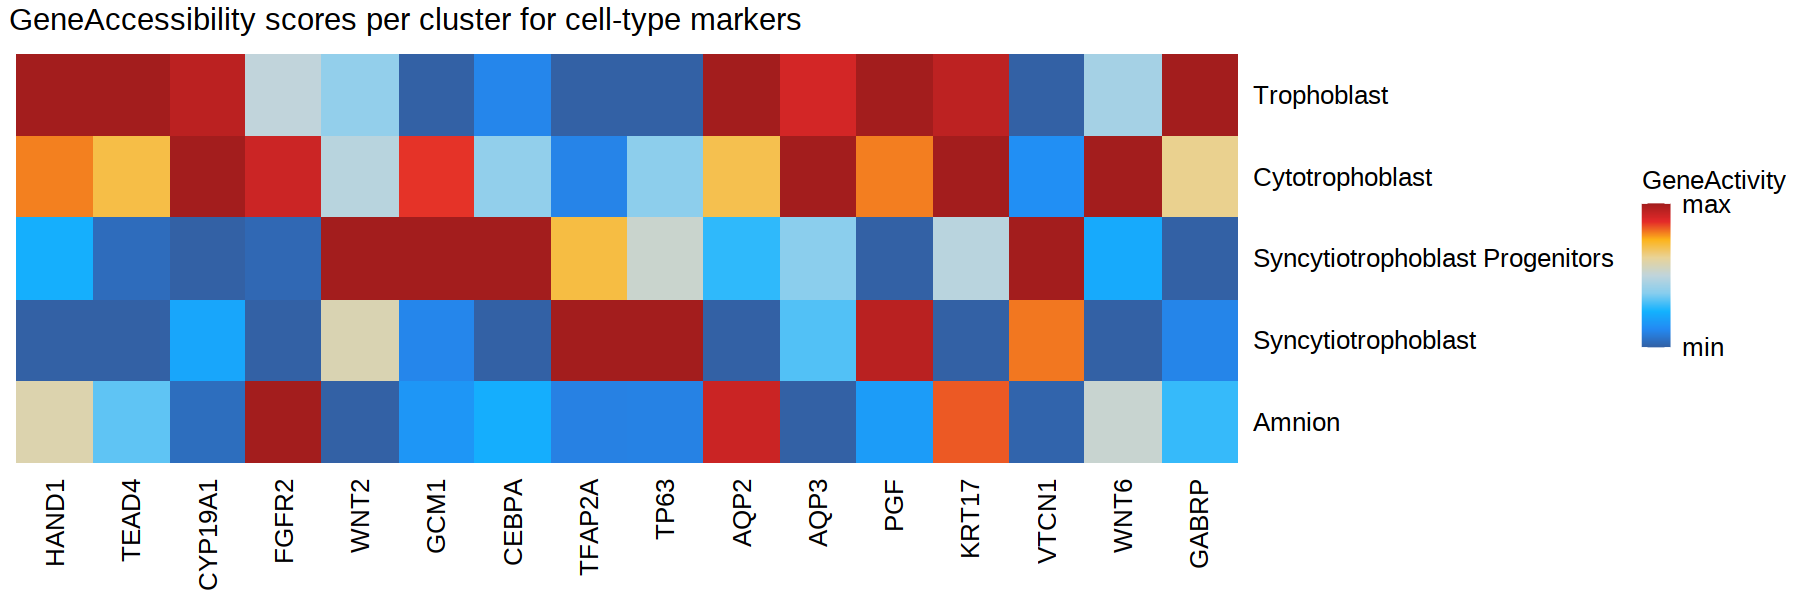

In [18]:
markers_Dan = c('HAND1', 
                'TEAD4',
                'CYP19A1', 
                'FGFR2', 
                'WNT2', 
                'GCM1', 
                'CEBPA',
                'TFAP2A', 
                'TFAP2C', 
                'TP63', 
                'CDX2', 
                'AQP2', 
                'AQP3', 
                'PGF', 
                'KRT17', 
                'VTCN1', 
                'WNT6', 
                'GABRP', 
                'ISL')

ggplot(plot[gene %in% markers_Dan], aes(factor(gene, levels=markers_Dan), 
                                        factor(celltype_tropho, levels = rev(celltype_tropho_levels)), 
                                        fill=value)) +  # factor(gene, levels=unique(markers$marker))
        geom_tile() + 
      #  facet_grid(factor(celltype, levels = rev(celltype_levels))~., scales ='free_y', space = "free") + 
        ylab('Cell-type Markers') + xlab('Marker') +
        ggtitle('GeneAccessibility scores per cluster for cell-type markers') + 
        scale_fill_gradientn(colors = paletteContinuous(), name='GeneActivity', breaks = c(0, 1), labels = c("min", "max")) +
#scale_color_continuous(breaks = c(0, 100), labels = c("min", "max"))
        scale_y_discrete(position = "right") +
        theme_classic() + theme(text = element_text(size = 15, colour='black'), 
                                axis.text.y = element_text(hjust=1, size = 15, colour='black'),
                                axis.text.x = element_text(size = 15, colour='black', angle=90, hjust=1, vjust=0.5),
                                axis.line.x = element_blank(),
                                axis.line.y = element_blank(),
                                axis.ticks = element_blank(), 
                                axis.title = element_blank(), 
                                strip.text.y = element_text(angle = 0, size=10),
                                legend.text = element_text(size=15))

In [19]:
# Remove Amnion for final plot

counts.mod = counts(sce_pseudobulk[, sce_pseudobulk$celltype_tropho != 'Amnion'])
# Minmax normalisation after pseudobulking
counts.mod = apply(counts.mod, 1, minmax) %>% t()


In [20]:
plot = as.data.table(t(counts.mod), keep.rownames=T) %>% 
        setnames('rn', 'celltype_tropho') %>%
        melt(id.vars =  'celltype_tropho') %>%
        unique(by=c('variable', 'value', 'celltype_tropho')) %>%
        setnames('variable', 'gene') %>%
        .[, celltype_tropho:= gsub('Syncytiotrophoblast',  'SCT', celltype_tropho)]

In [21]:
celltype_tropho_levels = gsub('Syncytiotrophoblast',  'SCT', celltype_tropho_levels)

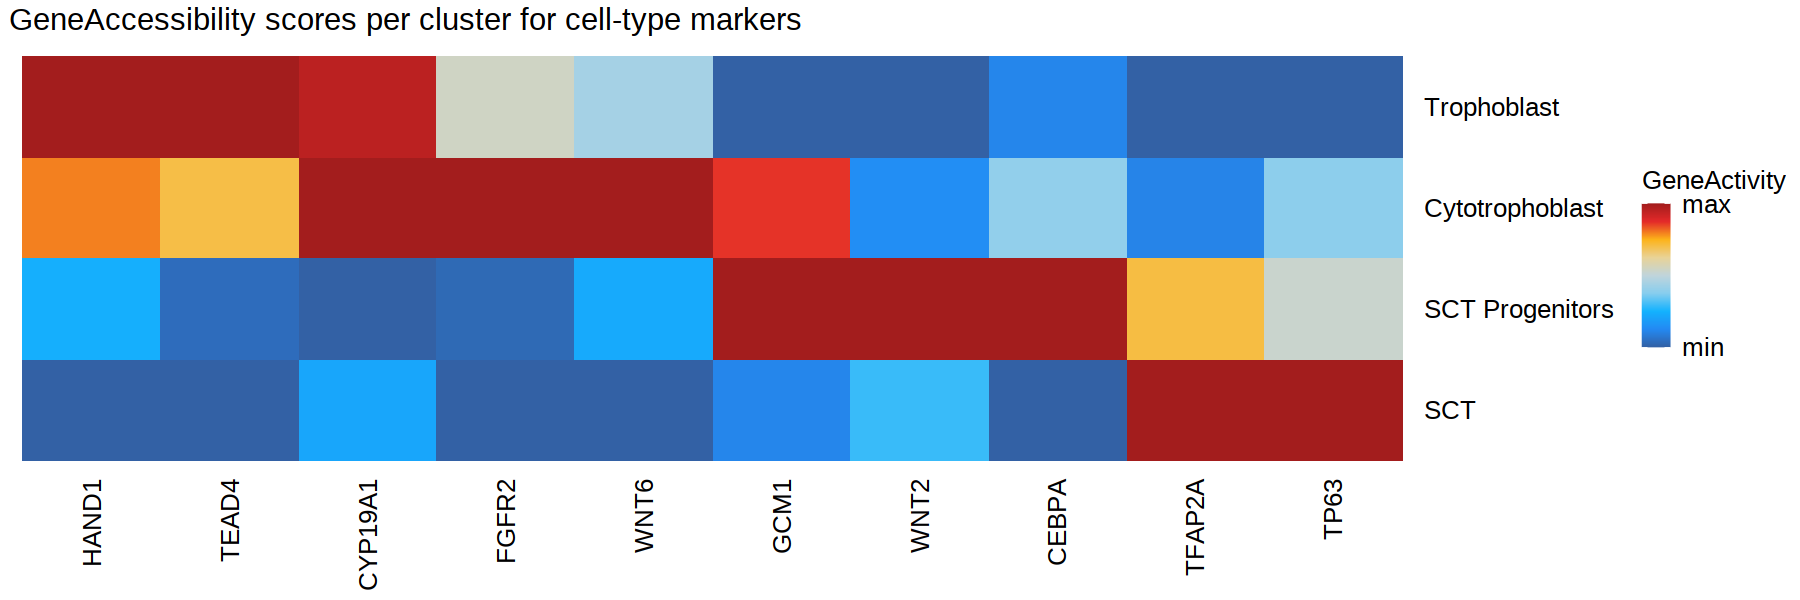

In [22]:
markers_Dan = c('HAND1', 
                'TEAD4',
                'CYP19A1', 
                'FGFR2',
                'WNT6',
                'GCM1', 
                'WNT2', 
                'CEBPA',
                'TFAP2A', 
                'TFAP2C', 
                'TP63')

p = ggplot(plot[gene %in% markers_Dan], aes(factor(gene, levels=markers_Dan), 
                                        factor(celltype_tropho, levels = rev(celltype_tropho_levels)), 
                                        fill=value)) +  # factor(gene, levels=unique(markers$marker))
        geom_tile() + 
      #  facet_grid(factor(celltype, levels = rev(celltype_levels))~., scales ='free_y', space = "free") + 
        ylab('Cell-type Markers') + xlab('Marker') +
        ggtitle('GeneAccessibility scores per cluster for cell-type markers') + 
        scale_fill_gradientn(colors = paletteContinuous(), name='GeneActivity', breaks = c(0, 1), labels = c("min", "max")) +
        scale_y_discrete(position = "right") +
        theme_classic() + theme(text = element_text(size = 15, colour='black'), 
                                axis.text.y = element_text(hjust=1, size = 15, colour='black'),
                                axis.text.x = element_text(size = 15, colour='black', angle=90, hjust=1, vjust=0.5),
                                axis.line.x = element_blank(),
                                axis.line.y = element_blank(),
                                axis.ticks = element_blank(), 
                                axis.title = element_blank(), 
                                strip.text.y = element_text(angle = 0, size=10),
                                legend.text = element_text(size=15))
p

In [24]:
fwrite(plot[gene %in% markers_Dan], '/rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/Figures_data_NCB/S6F_tropho_GeneAccessibility.csv')

In [35]:
# pdf(sprintf('%s/tropho_markers_accessibility.pdf', io$plot.trophoblast), width=10, height=5, onefile=T)
#     p
# dev.off()

png 
  2

### Motif enrichment

In [26]:
plot_enr_heatmap = function(enrichMotifs, ntop=25, TF_family=TRUE, TF_keep=c(NULL)) {
    heatmapEM <- plotEnrichHeatmap(enrichMotifs, n = ntop, returnMatrix = TRUE)
    celltype_tropho_levels = gsub('Syncytiotrophoblast',  'SCT', celltype_tropho_levels)
    
    enriched.dt = melt(as.data.table(heatmapEM, keep.rownames=T) %>% setnames('rn', 'TF'), id.vars = c("TF")) %>%
        .[order(-value)] 
    keep_tfs = enriched.dt[, head(.SD, ntop),  by=variable]$TF
    enriched.dt = enriched.dt[TF %in% keep_tfs] %>% .[order( -value)] %>% 
        .[,TF:=strsplit(TF, '_') %>% map_chr(1)] %>%
        .[,TF_family:=sub("[0-9].*$", "", TF)] %>%
        .[,TF_family:=ifelse(TF_family=='TFAP', TF, TF_family)] %>% # restory TFAP bc TFAP2D behaves different
        .[,TF_family:=ifelse(TF_family=='E', 'E2F', TF_family)] %>% # E2F cut off too short
        .[, variable:= gsub('Syncytiotrophoblast',  'SCT', variable)] %>%
         .[,variable:=factor(variable, levels=rev(celltype_tropho_levels))] %>%
         .[order(-value, variable, TF_family)] %>% 
         .[,TF:=factor(TF, levels=rev(unique(TF)))]
    
    if(!is.null(TF_keep)){
        enriched.dt = enriched.dt[TF %in% TF_keep]
    }
    
    p = ggplot(enriched.dt, aes(TF, variable, fill=value)) + 
    geom_tile(col='black') + 
    scale_fill_gradient2(low='grey80', high='darkblue', name='Norm. Enrichment -log10(P-adj) [0-max]', position='bottom') + 
    scale_y_discrete(position = "right") +
    guides(fill = guide_legend(title.position = "top")) +
    theme_classic() + theme(text = element_text(size = 15, colour='black'), 
                            axis.text.y = element_text(hjust=1, size = 15, colour='black'),
                            axis.text.x = element_text(size = 15, colour='black', angle=90, hjust=1, vjust=0.5),
                            axis.line.x = element_blank(),
                            axis.line.y = element_blank(),
                            axis.ticks = element_blank(), 
                            axis.title = element_blank(), 
                            strip.text.y = element_text(angle = 0, size=10),
                            legend.text = element_text(size=15),
                            legend.position='bottom')

    if(TF_family==TRUE){
    enriched.dt = enriched.dt %>%
        unique(by=c('TF_family', 'variable')) %>% 
         .[,TF_family:=factor(TF_family, levels=unique(TF_family))]
        
    p = ggplot(enriched.dt, aes(TF_family, variable, fill=value)) + 
        geom_tile(col='black') + 
        #viridis::scale_fill_viridis(name='Norm. Enrichment -log10(P-adj) [0-max]') + 
        scale_fill_gradient2(low='grey80', high='darkblue', name='Norm. Enrichment -log10(P-adj) [0-max]') + 
        scale_y_discrete(position = "right") +
        theme_classic() + theme(text = element_text(size = 15, colour='black'), 
                            axis.text.y = element_text(hjust=1, size = 15, colour='black'),
                            axis.text.x = element_text(size = 15, colour='black', angle=90, hjust=1, vjust=0.5),
                            axis.line.x = element_blank(),
                            axis.line.y = element_blank(),
                            axis.ticks = element_blank(), 
                            axis.title = element_blank(), 
                            strip.text.y = element_text(angle = 0, size=10),
                            legend.text = element_text(size=15),
                               legend.position='bottom')
        
    }


    return(p)
}

In [27]:
subset = ArchRProject[ArchRProject$celltype_tropho!='Amnion',]

Dropping ImputeWeights Since You Are Subsetting Cells! ImputeWeights is a cell-x-cell Matrix!



In [28]:
addArchRThreads(1)

Setting default number of Parallel threads to 1.



In [29]:
markersPeaks <- getMarkerFeatures(
    ArchRProj = ArchRProject, 
    useMatrix = "PeakMatrix", 
    groupBy = "celltype_tropho",
  bias = c("TSSEnrichment", "log10(nFrags)"),
  testMethod = "wilcoxon",
    verbose=T
)

In [30]:
markersPeaks

class: SummarizedExperiment 
dim: 332773 5 
metadata(2): MatchInfo Params
assays(7): Log2FC Mean ... AUC MeanBGD
rownames(332773): 1 2 ... 332772 332773
rowData names(4): seqnames idx start end
colnames(5): Amnion Cytotrophoblast Syncytiotrophoblast
  Syncytiotrophoblast Progenitors Trophoblast
colData names(0):

In [31]:
colnames(markersPeaks) = gsub('Syncytiotrophoblast',  'SCT', colnames(markersPeaks))

In [32]:
markersPeaks = markersPeaks[,colnames(markersPeaks) != 'Amnion']

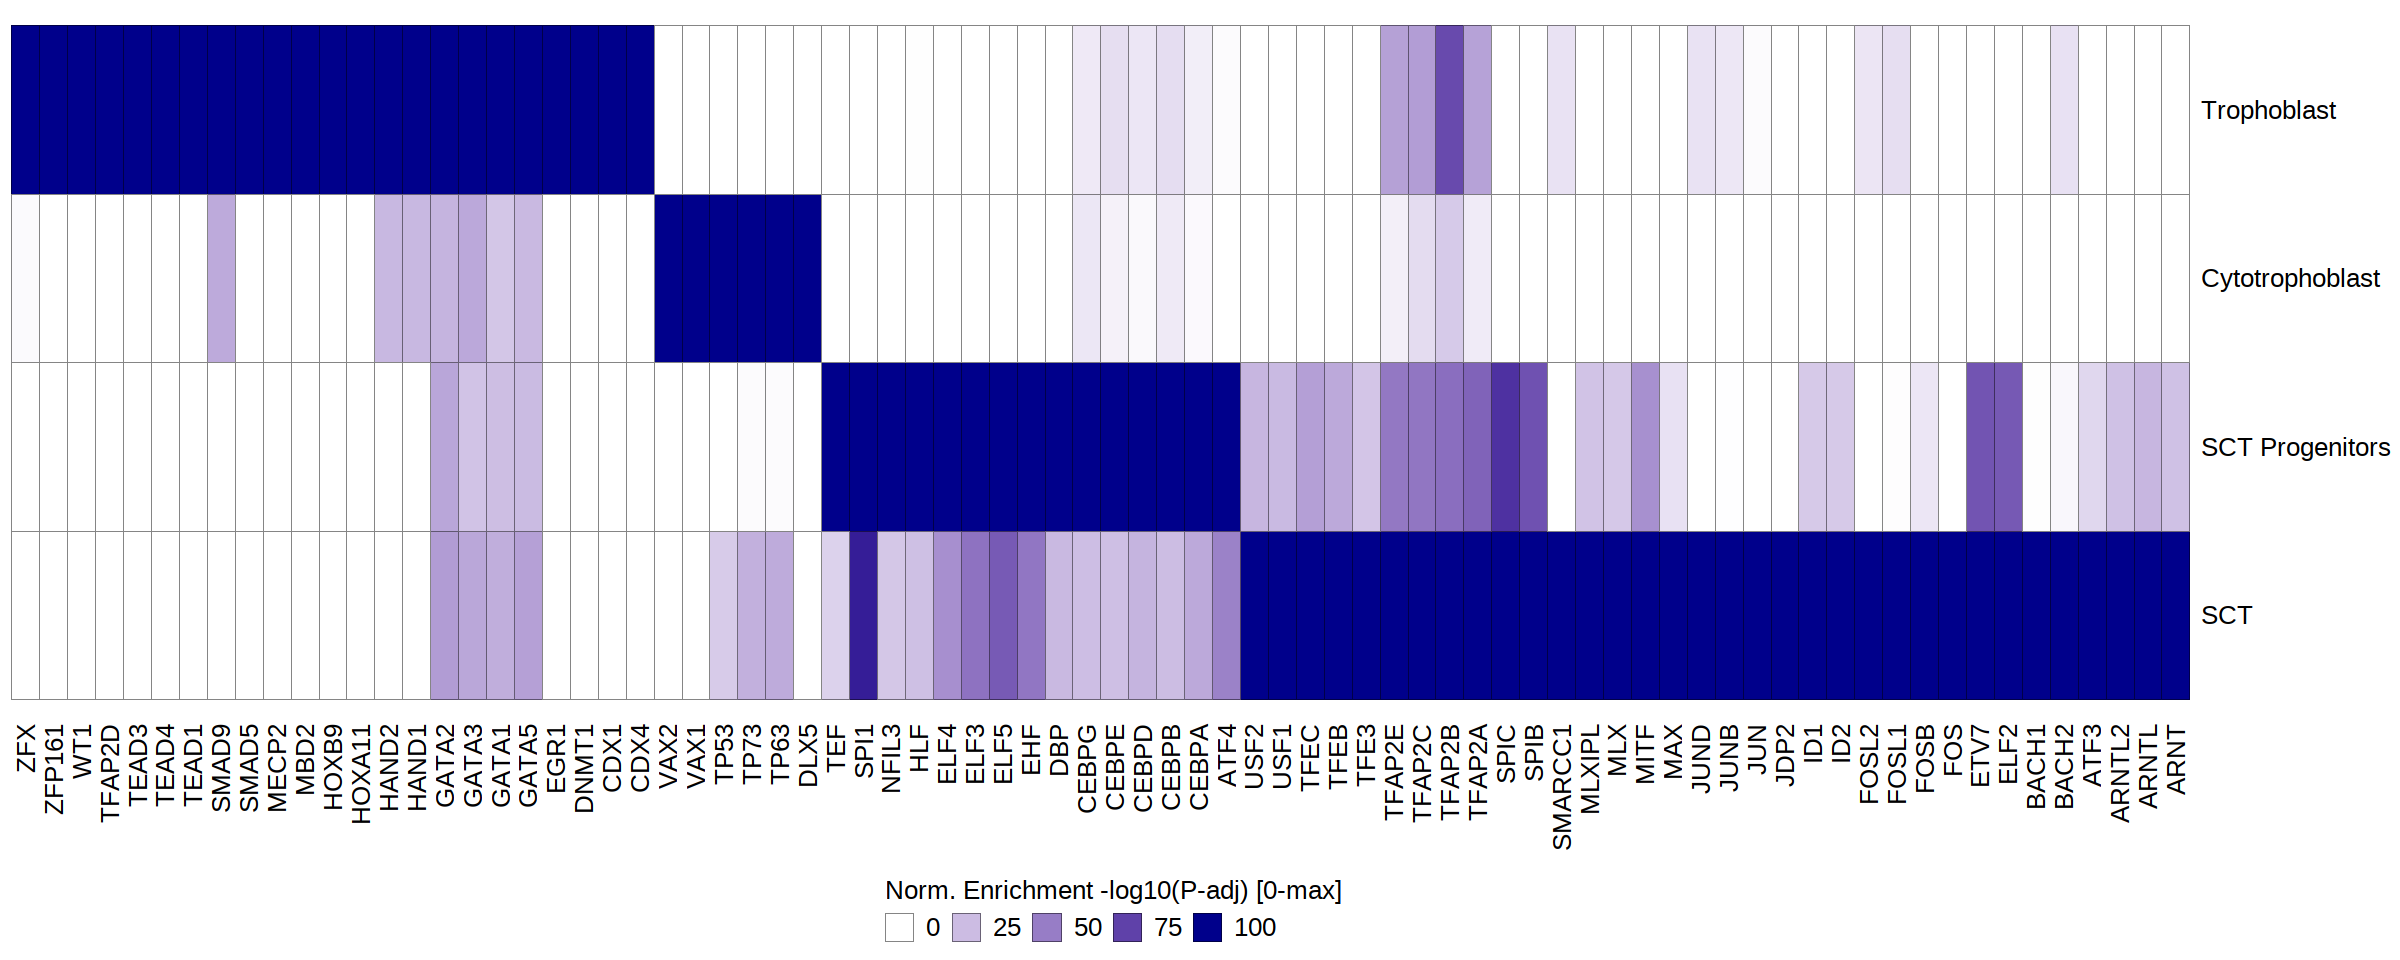

In [33]:
motifs <- peakAnnoEnrichment(
    seMarker = markersPeaks,
    ArchRProj = subset,
    peakAnnotation = "Motif",
    cutOff = "FDR <= 0.05 & Log2FC >= 0.5"
  )
options(repr.plot.width=20, repr.plot.height=8)
p = plot_enr_heatmap(motifs, ntop = 1000, TF_family=F)
p

In [88]:
# pdf(sprintf('%s/tropho_peak_enrichment.pdf', io$plot.trophoblast), width=18, height=6, onefile=T)
#     plot_enr_heatmap(motifs, ntop = 1000, TF_family=F)
# dev.off()

png 
  2

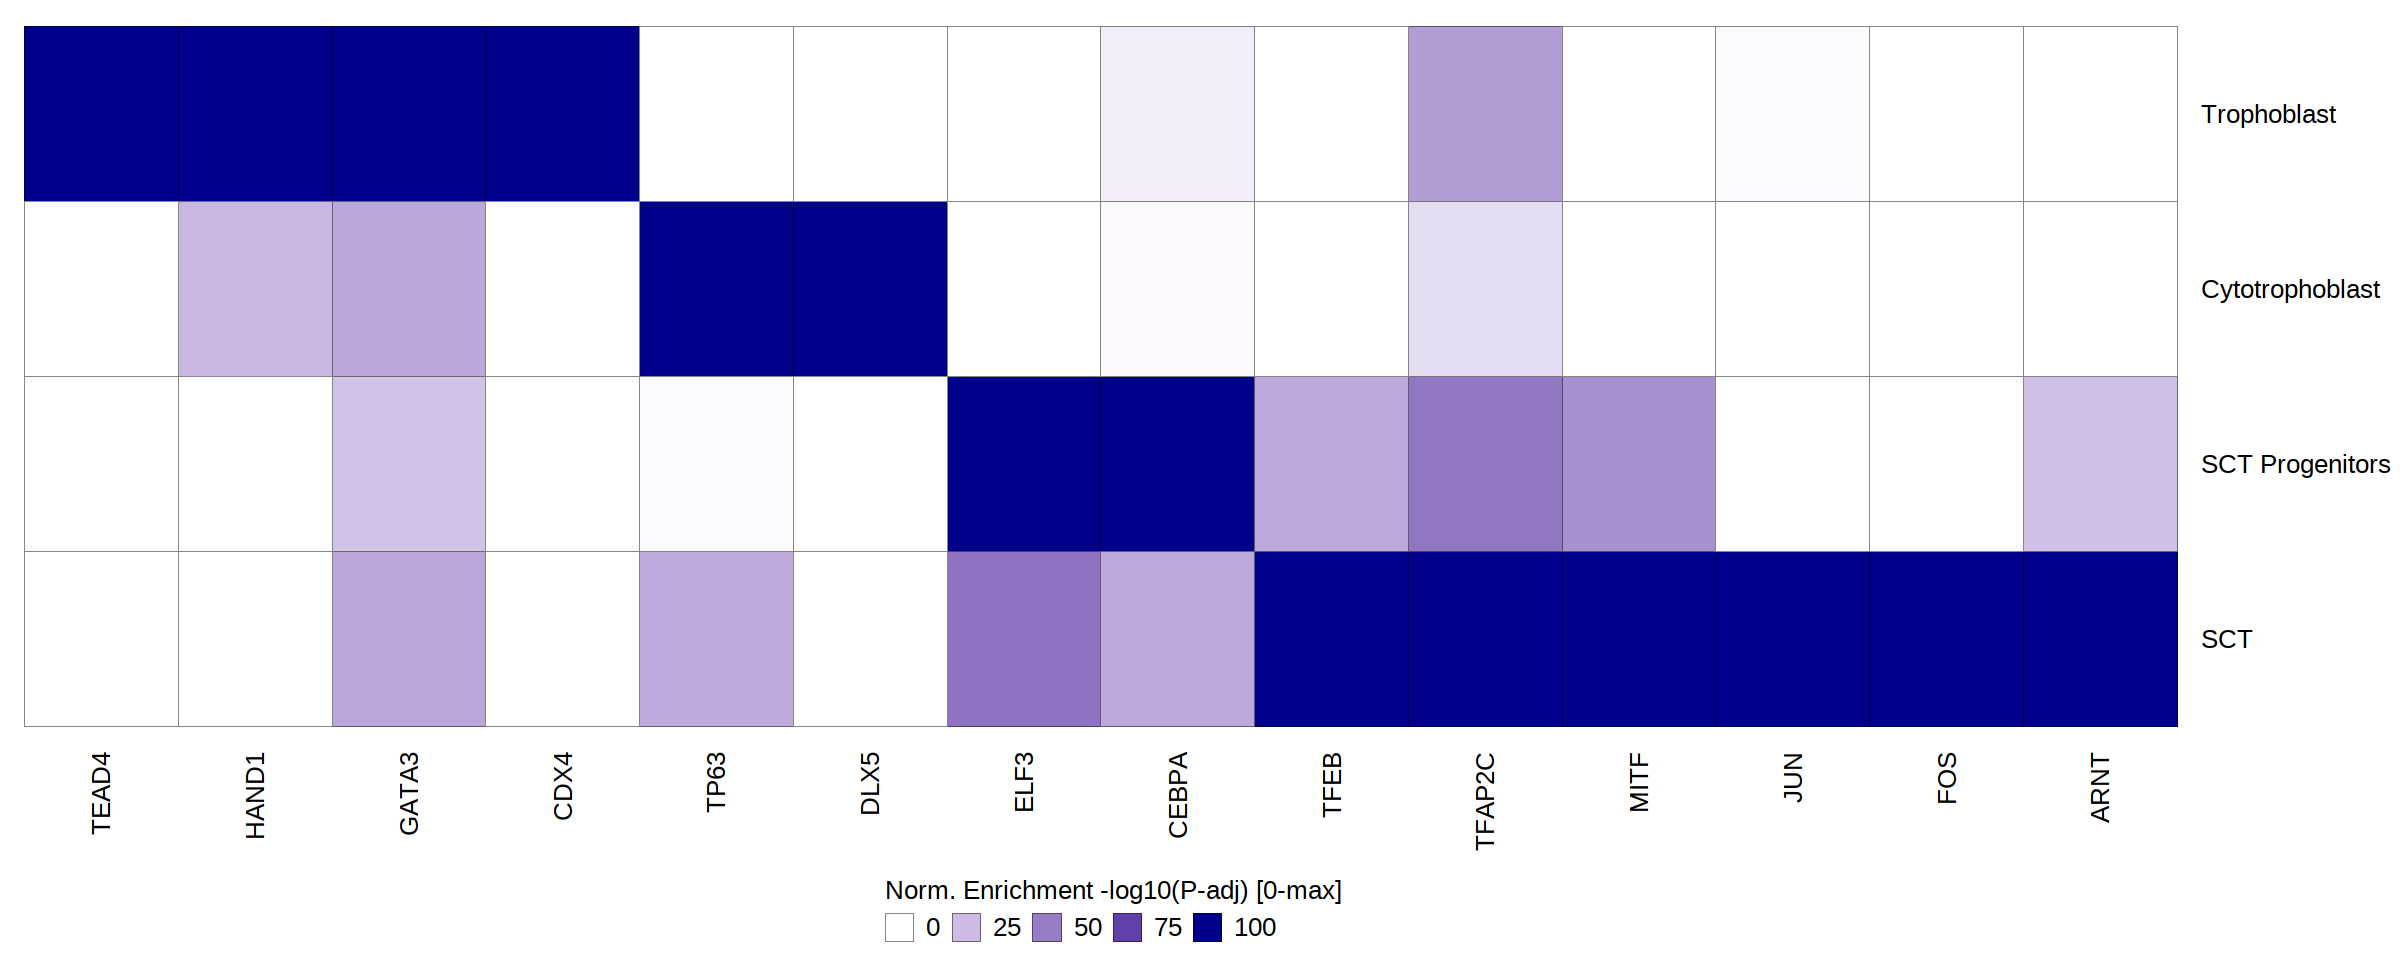

In [34]:
TFs_to_keep = c('CDX4', 'GATA3', 'HAND1', 'TEAD4',
                'DLX5', 'TP63', 
                'CEBPA', 'ELF3', 
                'TFAP2C', 'MITF', 'TFEB', 'FOS', 'JUN', 'ARNT')
p = plot_enr_heatmap(motifs, ntop = 1000, TF_family=F, TF_keep=TFs_to_keep)
p

In [40]:
TF_keep = TFs_to_keep
enrichMotifs = motifs
ntop = 1000
TF_family = F

heatmapEM <- plotEnrichHeatmap(enrichMotifs, n = ntop, returnMatrix = TRUE)
celltype_tropho_levels = gsub('Syncytiotrophoblast',  'SCT', celltype_tropho_levels)

enriched.dt = melt(as.data.table(heatmapEM, keep.rownames=T) %>% setnames('rn', 'TF'), id.vars = c("TF")) %>%
    .[order(-value)] 
keep_tfs = enriched.dt[, head(.SD, ntop),  by=variable]$TF
enriched.dt = enriched.dt[TF %in% keep_tfs] %>% .[order( -value)] %>% 
    .[,TF:=strsplit(TF, '_') %>% map_chr(1)] %>%
    .[,TF_family:=sub("[0-9].*$", "", TF)] %>%
    .[,TF_family:=ifelse(TF_family=='TFAP', TF, TF_family)] %>% # restory TFAP bc TFAP2D behaves different
    .[,TF_family:=ifelse(TF_family=='E', 'E2F', TF_family)] %>% # E2F cut off too short
    .[, variable:= gsub('Syncytiotrophoblast',  'SCT', variable)] %>%
     .[,variable:=factor(variable, levels=rev(celltype_tropho_levels))] %>%
     .[order(-value, variable, TF_family)] %>% 
     .[,TF:=factor(TF, levels=rev(unique(TF)))]

enriched.dt = enriched.dt[TF %in% TF_keep]


In [96]:
# pdf(sprintf('%s/tropho_peak_enrichment_selected_TFs.pdf', io$plot.trophoblast), width=10, height=5, onefile=T)
#     plot_enr_heatmap(motifs, ntop = 1000, TF_family=F, TF_keep=TFs_to_keep)
# dev.off()

png 
  2

# QC plots specific for trophoblast

In [7]:
meta = as.data.table(ArchRProject@cellColData)

In [15]:
QC_plot = meta %>% 
    .[,c('Sample', 'TSSEnrichment', 'nFrags', 'FRIP', 'stage', 'celltype_tropho')] %>%
    melt(id.vars = c('Sample', 'stage', 'celltype_tropho'), variable.name='statistic', value.name='value') %>%
    .[,Sample:=gsub('rabbit_', '', Sample)]

In [21]:
opts$trophoblast_colours = opts$celltype_colours[names(opts$celltype_colours) %in%  unique(meta$celltype_tropho)]

In [23]:
opts$trophoblast_colours

Amnion                     Trophoblast 
                      "#549E79"                       "#989898" 
                Cytotrophoblast Syncytiotrophoblast Progenitors 
                      "#46c5bf"                       "#7766db" 
            Syncytiotrophoblast 
                      "#7295e2"

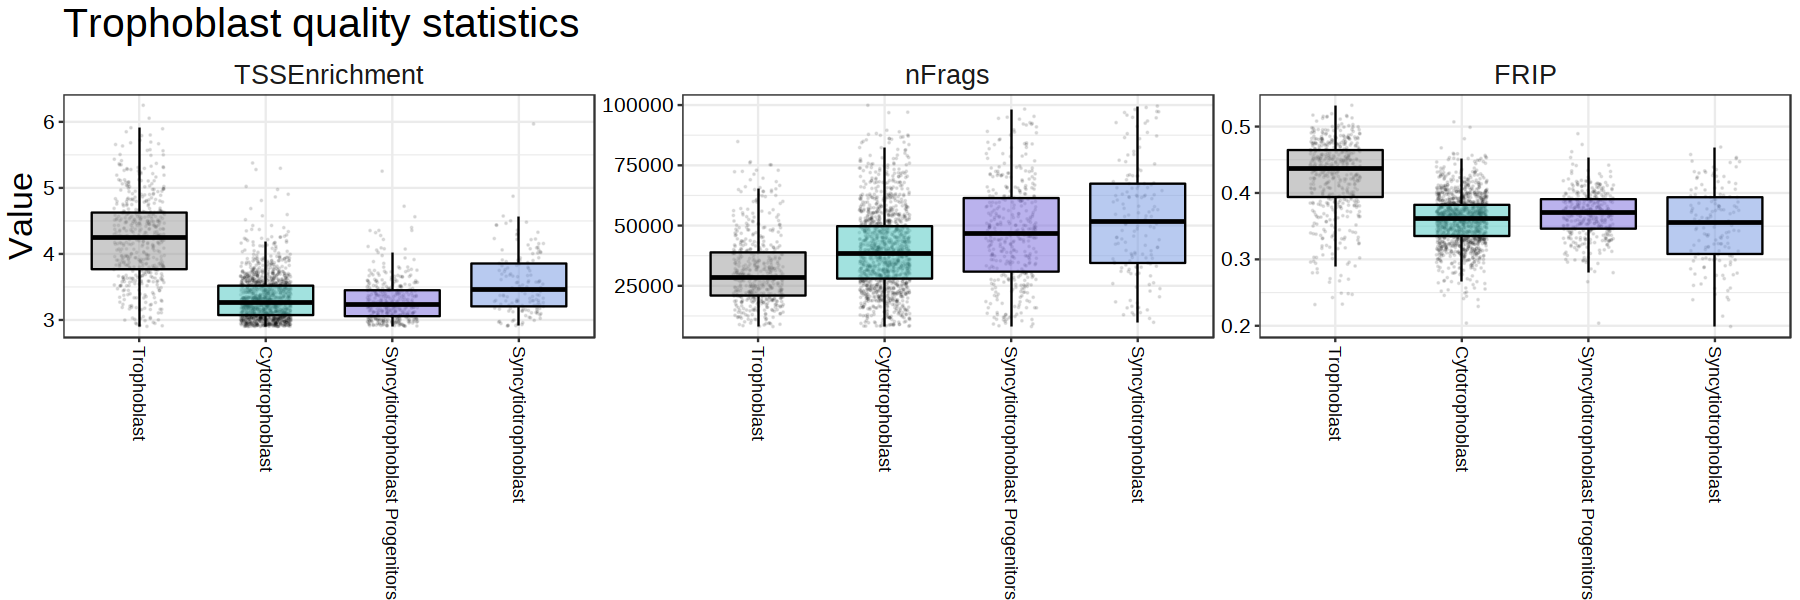

In [30]:
p = ggplot(QC_plot[celltype_tropho!='Amnion'], aes(factor(celltype_tropho, levels = celltype_tropho_levels), value)) + 
    geom_point(size=0.05, alpha=0.1, position=position_jitter(width = 0.2)) + 
    geom_boxplot(outlier.shape=NA, alpha=0.5, aes(fill=celltype_tropho), col='black') +
    scale_fill_manual(values=opts$trophoblast_colours) + 
    facet_wrap(~statistic, scales='free') +
    #ylim(0, NA) + 
    ylab('Value') + 
    ggtitle('Trophoblast quality statistics') + 
    theme_bw() +
    theme(
            legend.position = "none",
            legend.title = element_blank(),
            axis.text.x = element_text(colour="black",size=rel(0.65), angle=-90, hjust=0, vjust=0.5),  
            axis.text.y = element_text(colour="black",size=rel(0.75)),  
            axis.title.x = element_blank(),
            text=element_text(size=20, colour='black'),
            strip.background=element_blank()
        ) 
p 

In [33]:
pdf(sprintf("%s/trophoblast_quality_statistics.pdf",io$plot.trophoblast), width=9, height=5)
    p
dev.off()

png 
  2